<a href="https://colab.research.google.com/github/susritagagireddy/iiith-summer-internship/blob/main/week-4/Task_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [2]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
  inflating: dataset/data.yaml       
   creating: dataset/images/
   creating: dataset/images/test/
  inflating: dataset/images/test/frame_0141.jpg  
  inflating: dataset/images/test/frame_0142.jpg  
  inflating: dataset/images/test/frame_0143.jpg  
  inflating: dataset/images/test/frame_0144.jpg  
  inflating: dataset/images/test/frame_0145.jpg  
  inflating: dataset/images/test/frame_0146.jpg  
  inflating: dataset/images/test/frame_0147.jpg  
  inflating: dataset/images/test/frame_0148.jpg  
  inflating: dataset/images/test/frame_0149.jpg  
  inflating: dataset/images/test/frame_0150.jpg  
  inflating: dataset/images/test/frame_0151.jpg  
  inflating: dataset/images/test/frame_0152.jpg  
  inflating: dataset/images/test/frame_0153.jpg  
  inflating: dataset/images/test/frame_0154.jpg  
  inflating: dataset/images/test/frame_0155.jpg  
  inflating: dataset/images/test/frame_0156.jpg  
  inflating: dataset/images/test/frame_0157.jpg  
  inf

In [3]:
import os

label_dirs = [
    "dataset/labels/train",
    "dataset/labels/val"
]

for label_dir in label_dirs:

    for filename in os.listdir(label_dir):

        if filename.endswith(".txt"):

            old_path = os.path.join(label_dir, filename)

            # remove prefix before "frame"
            if "frame_" in filename:

                new_name = filename.split("frame_")[-1]
                new_name = "frame_" + new_name

                new_path = os.path.join(label_dir, new_name)

                os.rename(old_path, new_path)

print("Label filenames fixed!")


Label filenames fixed!


In [4]:
!ls dataset/labels/train | head

frame_0001.txt
frame_0002.txt
frame_0003.txt
frame_0004.txt
frame_0005.txt
frame_0006.txt
frame_0007.txt
frame_0008.txt
frame_0009.txt
frame_0010.txt


In [5]:
!rm dataset/labels/train.cache
!rm dataset/labels/val.cache

rm: cannot remove 'dataset/labels/train.cache': No such file or directory
rm: cannot remove 'dataset/labels/val.cache': No such file or directory


In [6]:
!find dataset/labels -name "*.cache"

In [7]:
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="dataset/data.yaml",
    epochs=10,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1d1c6e8710>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

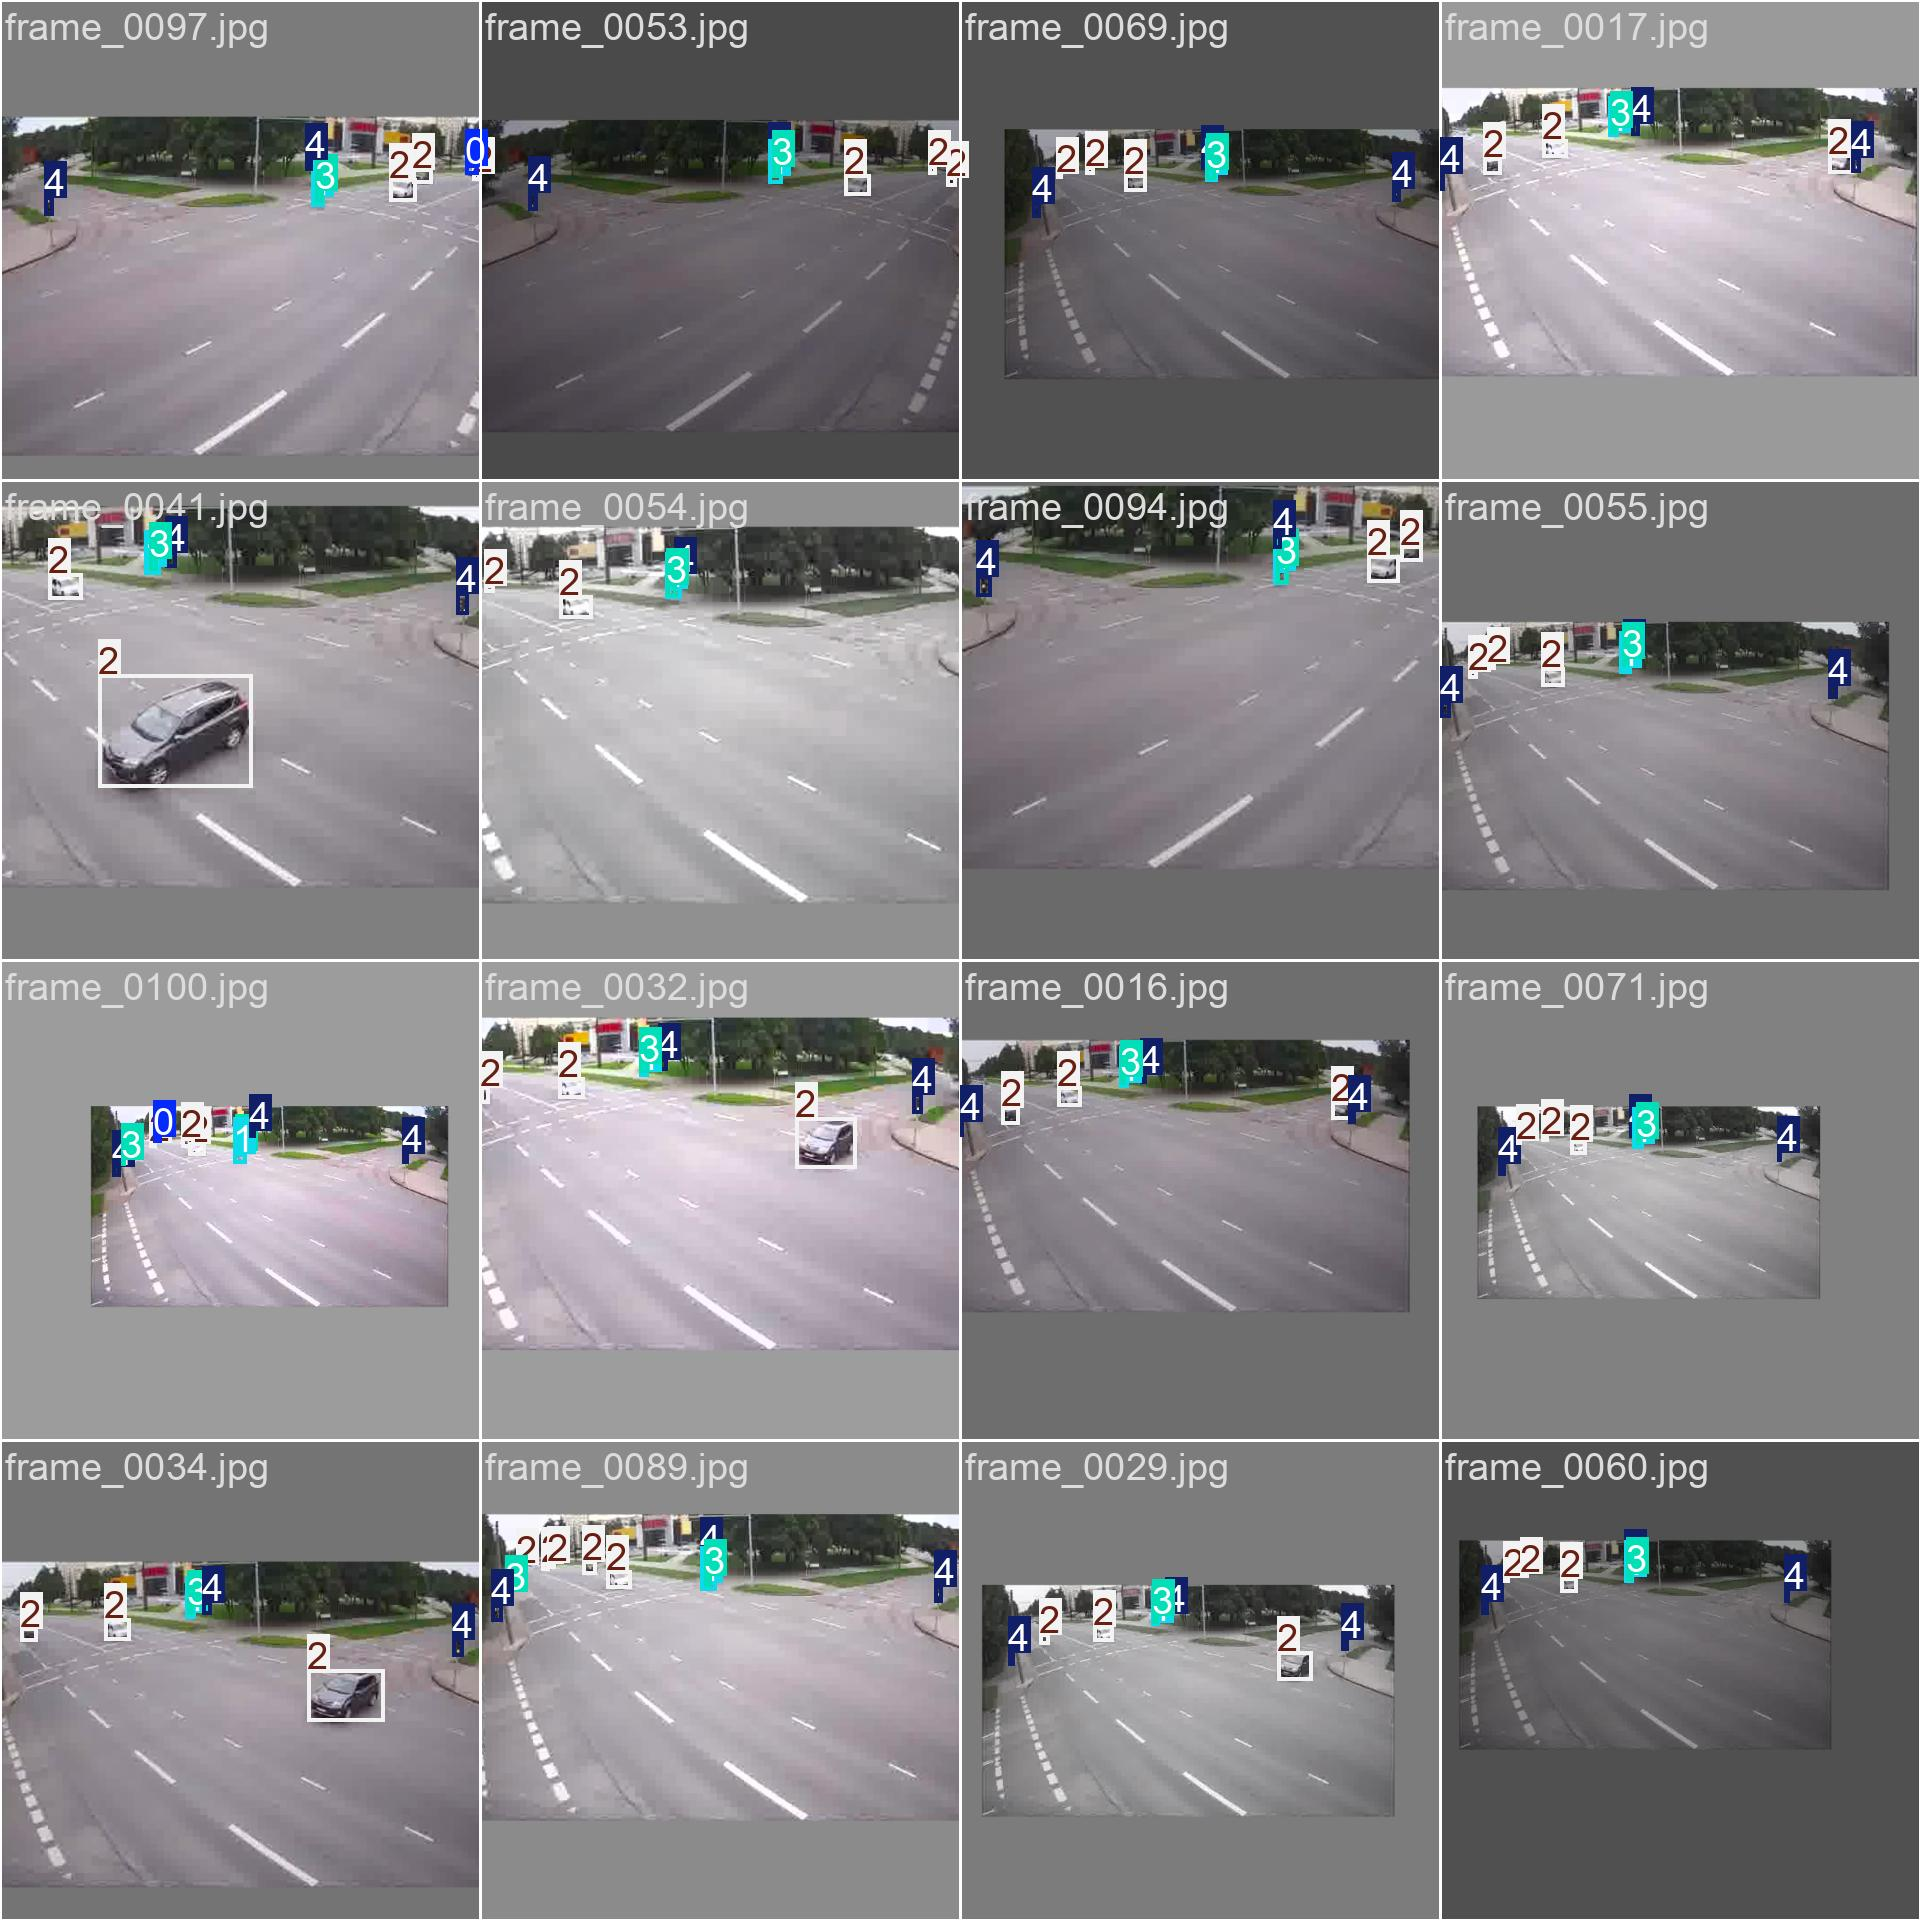

In [11]:
from IPython.display import Image

Image("/content/runs/detect/train/train_batch0.jpg")

In [16]:
!cat /content/dataset/labels/train/frame_0100.txt

2 0.703125 0.21278317152103562 0.046419902912621325 0.06310679611650485
3 0.5852548543689321 0.2346278317152104 0.01820388349514566 0.0323624595469256
1 0.5834344660194176 0.2588996763754045 0.03458737864077676 0.051779935275080895
4 0.12014563106796118 0.2588996763754045 0.018203883495145644 0.05501618122977345
4 0.5474817961165049 0.13592233009708737 0.015473300970873823 0.03883495145631066
4 0.9297633495145632 0.32362459546925565 0.022754854368932056 0.05501618122977348
3 0.9088288834951459 0.2791262679279839 0.011832524271844704 0.033980582524271837
2 0.7290655339805826 0.18203883495145629 0.03822815533980588 0.05339805825242719
2 0.8264563106796117 0.19012958567756505 0.01820388349514559 0.027508090614886703
0 0.8141686893203886 0.16262135922330095 0.022754854368931918 0.03398058252427187


In [17]:
!find /content/dataset/labels/train -name "*.txt" | wc -l

100


In [18]:
!find /content/dataset/images/train -name "*.jpg" | wc -l

100
